### Тема: Дробовий факторний експеримент
**Датасет**: [Red Wine Quality (UCI / Kaggle)](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009)

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats

#### **Завантаження даних та EDA**

Задача: змоделювати якість вина (quality) як функцію від 4-х фізико-хімічних факторів.

In [73]:
import kagglehub

path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")
print("Path to dataset files:", path)

Path to dataset files: /Users/mariia.m/.cache/kagglehub/datasets/uciml/red-wine-quality-cortez-et-al-2009/versions/2


In [74]:
import os

csv_path = os.path.join(path, 'winequality-red.csv')
df = pd.read_csv(csv_path, sep=',')

**1. Перевірка якості даних**

In [75]:
TARGET = 'quality'
features = [c for c in df.columns if c != TARGET]

print(f'Рядків: {df.shape[0]}')
print(f'Стовпців: {df.shape[1]}')
print(f'Пропущені значення: {df.isnull().sum().sum()}')
print(f'Повні дублікати: {df.duplicated().sum()}')
print()
df.head()

Рядків: 1599
Стовпців: 12
Пропущені значення: 0
Повні дублікати: 240



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Дублікати (12% від числа усіх записів) лишаємо, збіг хімічних показників можливий.

**2. Аналіз quality**

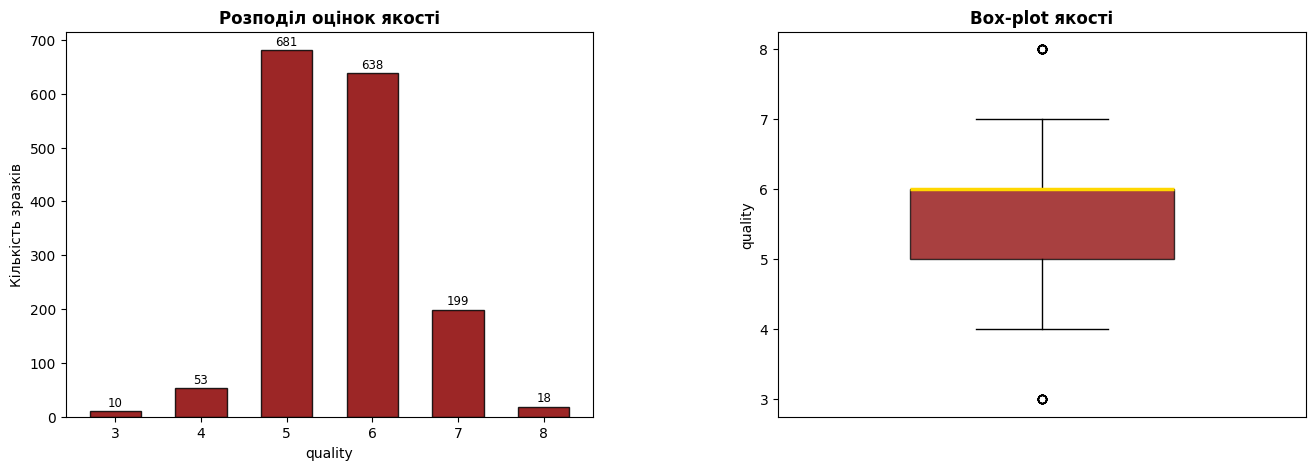

In [76]:
fig = plt.figure(figsize=(16, 5))
gs = GridSpec(1, 2, figure=fig, wspace=0.35)

# Гістограма
ax1 = fig.add_subplot(gs[0])
counts = df[TARGET].value_counts().sort_index()
bars = ax1.bar(counts.index, counts.values, color='#8B0000',
               edgecolor='black', alpha=0.85, width=0.6)
ax1.set_title('Розподіл оцінок якості', fontweight='bold')
ax1.set_xlabel('quality')
ax1.set_ylabel('Кількість зразків')
ax1.set_xticks(counts.index)
for bar, (x, y) in zip(bars, zip(counts.index, counts.values)):
    ax1.text(x, y + 4, f'{y}',
             ha='center', fontsize=8.5, va='bottom')

# Boxplot
ax2 = fig.add_subplot(gs[1])
bp = ax2.boxplot(df[TARGET], patch_artist=True, widths=0.5,
                 medianprops=dict(color='gold', lw=2.5))
bp['boxes'][0].set_facecolor('#8B0000')
bp['boxes'][0].set_alpha(0.75)
q1, med, q3 = df[TARGET].quantile([.25, .5, .75])
ax2.set_title('Box-plot якості', fontweight='bold')
ax2.set_xticks([])
ax2.set_ylabel('quality')

plt.show()

Діапазон значень: 3-8. 

Наяний дисбаланс класів - 82.5% зразків мають quality 5 або 6. Але для ДФЕ не критично, мии регресуємо середнє значення, а не класифікуємо.

**3. Аналіз розподілів і викидів факторів**

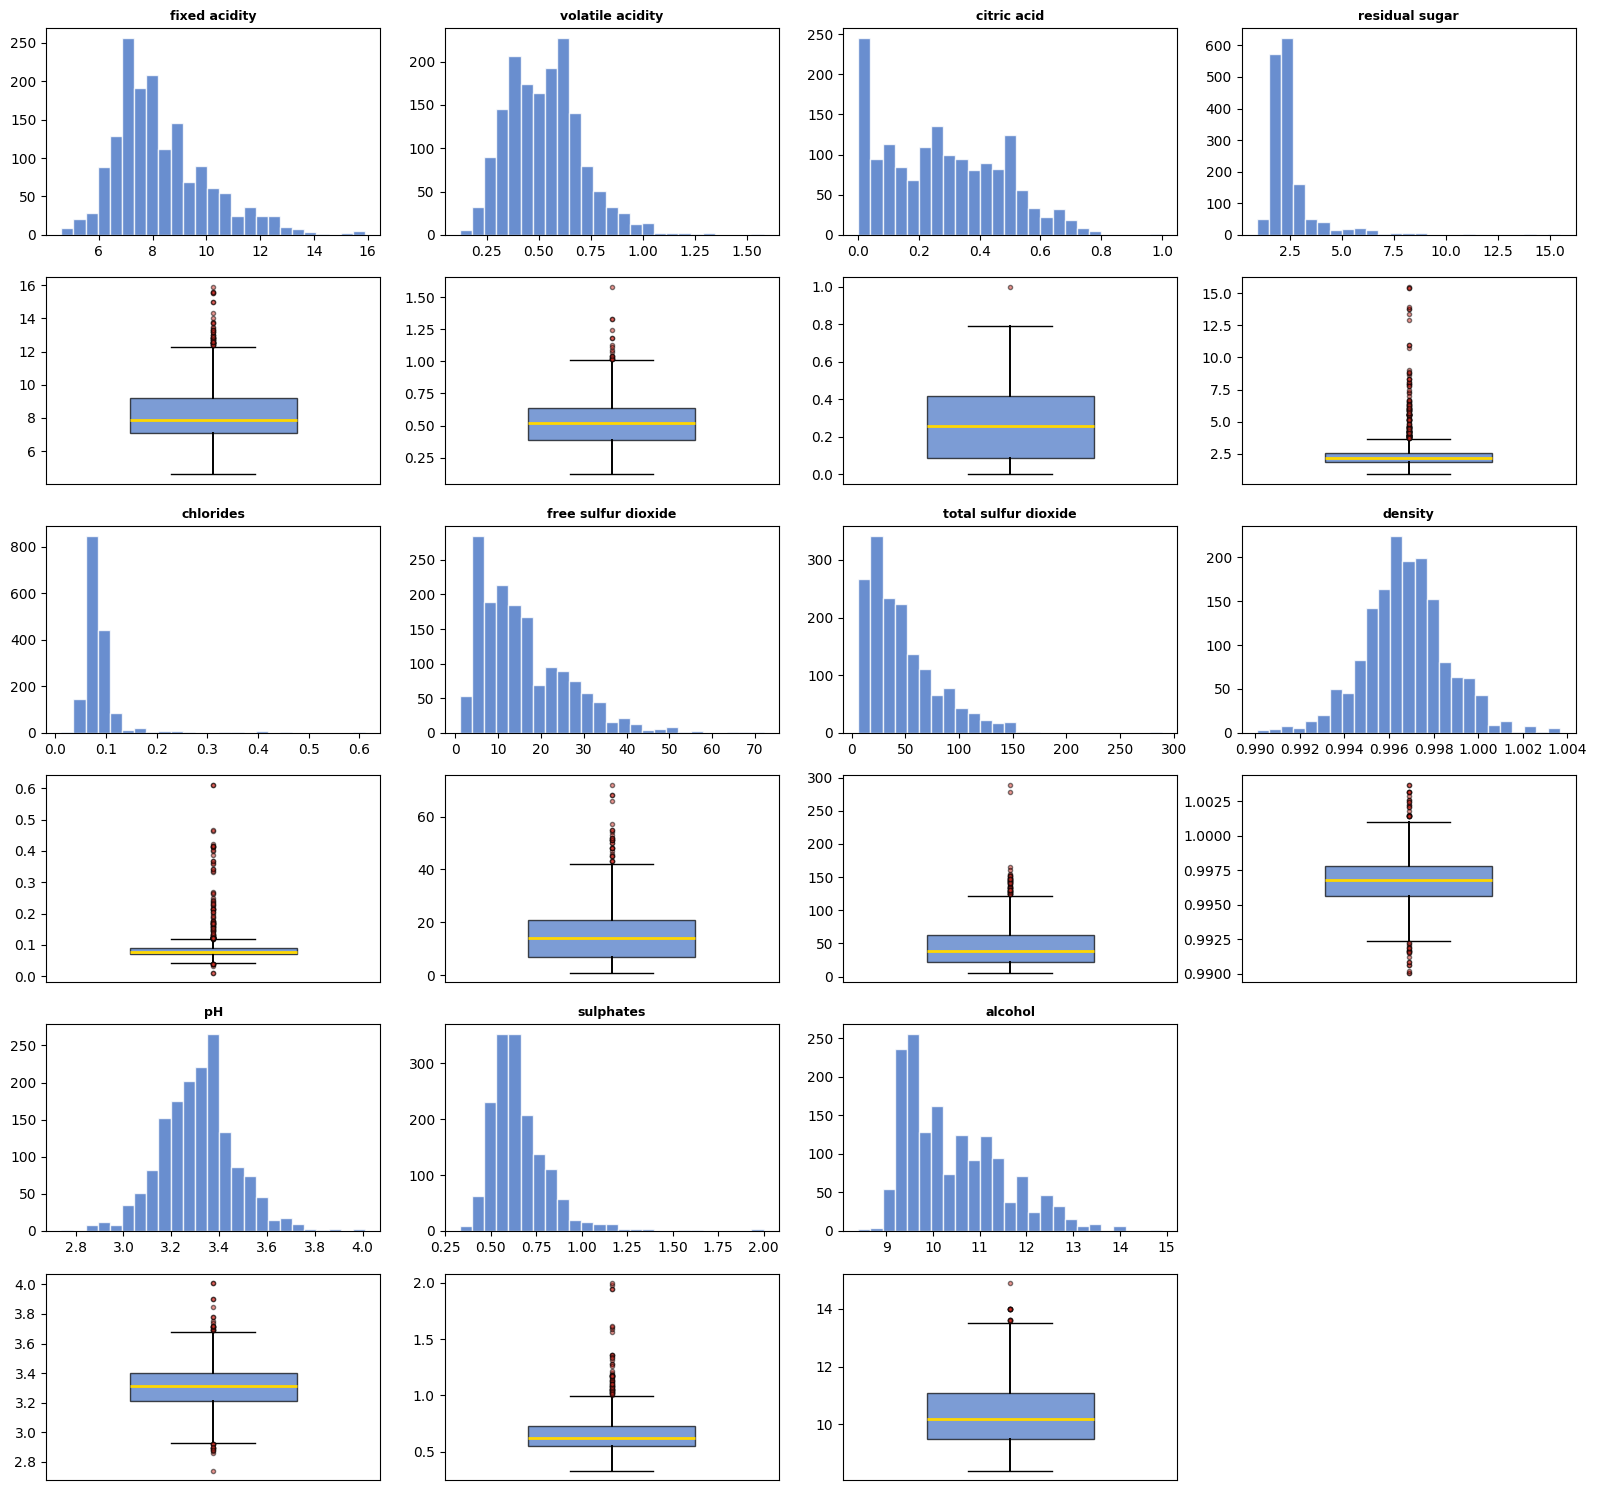

In [77]:
import math

N_COLS = 4
n_chunks = math.ceil(len(features) / N_COLS)

fig, axes = plt.subplots(
    n_chunks * 2, N_COLS,
    figsize=(N_COLS * 4, n_chunks * 5)
)

outlier_info = {}

for feat_i, feat in enumerate(features):
    chunk = feat_i // N_COLS
    col   = feat_i %  N_COLS
    ax1 = axes[chunk * 2,     col]
    ax2 = axes[chunk * 2 + 1, col]

    data = df[feat]
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr   = q3 - q1
    n_out = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    outlier_info[feat] = n_out

    # Гістограма
    ax1.hist(data, bins=25, color='#4472C4', edgecolor='white', alpha=0.8)
    ax1.set_title(feat[:20], fontweight='bold', fontsize=9)

    # Boxplot
    bp = ax2.boxplot(data, patch_artist=True, widths=0.5,
                     flierprops=dict(marker='o', markerfacecolor='#d73027',
                                     markersize=3, alpha=0.5, linestyle='none'),
                     medianprops=dict(color='gold', lw=2),
                     whiskerprops=dict(lw=1.4))
    bp['boxes'][0].set_facecolor('#4472C4')
    bp['boxes'][0].set_alpha(0.7)
    ax2.set_xticks([])

for feat_i in range(len(features), n_chunks * N_COLS):
    chunk = feat_i // N_COLS
    col   = feat_i %  N_COLS
    axes[chunk * 2,     col].set_visible(False)
    axes[chunk * 2 + 1, col].set_visible(False)

plt.tight_layout()
plt.show()

Описова статистика з виведенням 95 та 99 перцентиля:

In [78]:
df.describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]).round(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,5.636
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.808
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,6.000
95%,11.800,0.840,0.600,5.100,0.126,35.000,112.100,1.000,3.570,0.930,12.500,7.000
99%,13.300,1.020,0.700,8.306,0.360,50.020,145.000,1.002,3.700,1.260,13.400,8.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000


Очистимо викиди за 99% для ознак з явним відривом хвоста:

In [79]:
cols_to_clip = [
    'chlorides',
    'residual sugar', 
    'total sulfur dioxide',
    'free sulfur dioxide',
    'sulphates',
]

df_clean = df.copy()
for col in cols_to_clip:
    p99 = df[col].quantile(0.99)
    df_clean = df_clean[df_clean[col] <= p99]

print(f'Рядків до очищення: {len(df)}')
print(f'Рядків після: {len(df_clean)}')
print(f'Видалено: {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.1f}%)')

Рядків до очищення: 1599
Рядків після: 1532
Видалено: 67 (4.2%)


**4. Кореляційний аналіз факторів з цільовою змінною (quality)**

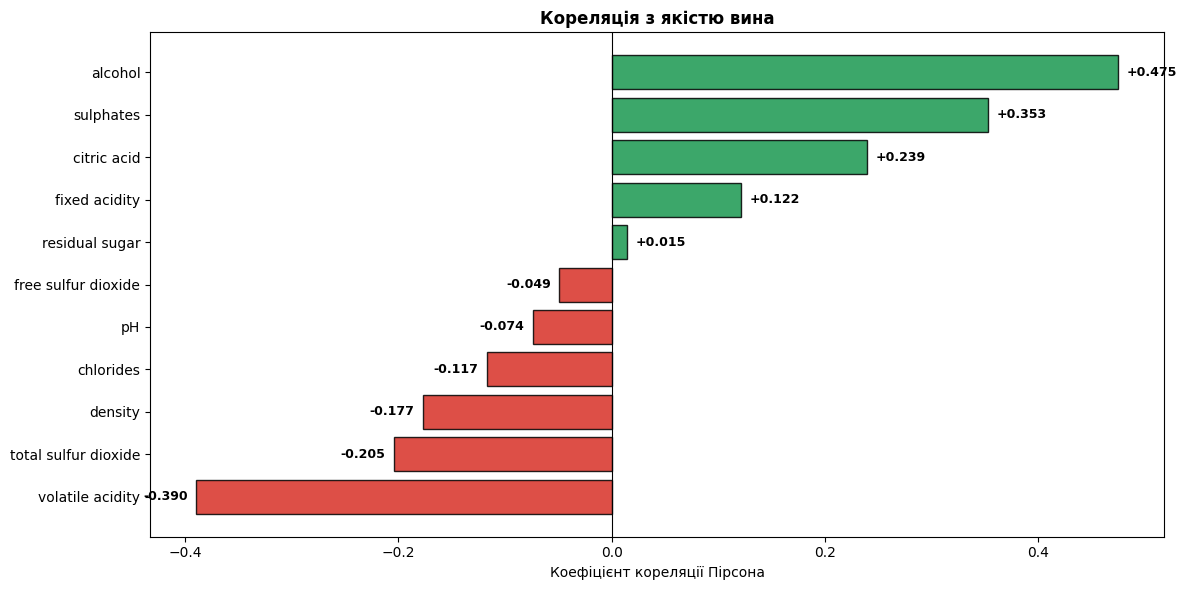

Кореляції (відсортовано за модулем):
alcohol                 0.474974
volatile acidity       -0.389625
sulphates               0.352815
citric acid             0.239285
total sulfur dioxide   -0.204503
density                -0.177343
fixed acidity           0.121501
chlorides              -0.117083
pH                     -0.073665
free sulfur dioxide    -0.049088
residual sugar          0.014639


In [80]:
corr = df_clean.corr()[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#1a9850' if v > 0 else '#d73027' for v in corr.values]
bars = ax.barh(corr.index, corr.values, color=colors, edgecolor='black', alpha=0.85)
ax.axvline(0, color='black', lw=0.8)

for bar, v in zip(bars, corr.values):
    xpos = v + 0.008 if v >= 0 else v - 0.008
    ha = 'left' if v >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{v:+.3f}', va='center', ha=ha, fontsize=9, fontweight='bold')

ax.set_title('Кореляція з якістю вина', fontweight='bold')
ax.set_xlabel('Коефіцієнт кореляції Пірсона')
plt.tight_layout()
plt.show()

print('Кореляції (відсортовано за модулем):')
corr.sort_values(key=abs, ascending=False, inplace=True)
print(corr.to_string())

Виключаємо фактори з мінімальною кореляцією з цільовою змінною:

In [81]:
candidates = corr[corr.abs() >= 0.1].index.tolist()

**5. Перевірка мультиколінеарності**

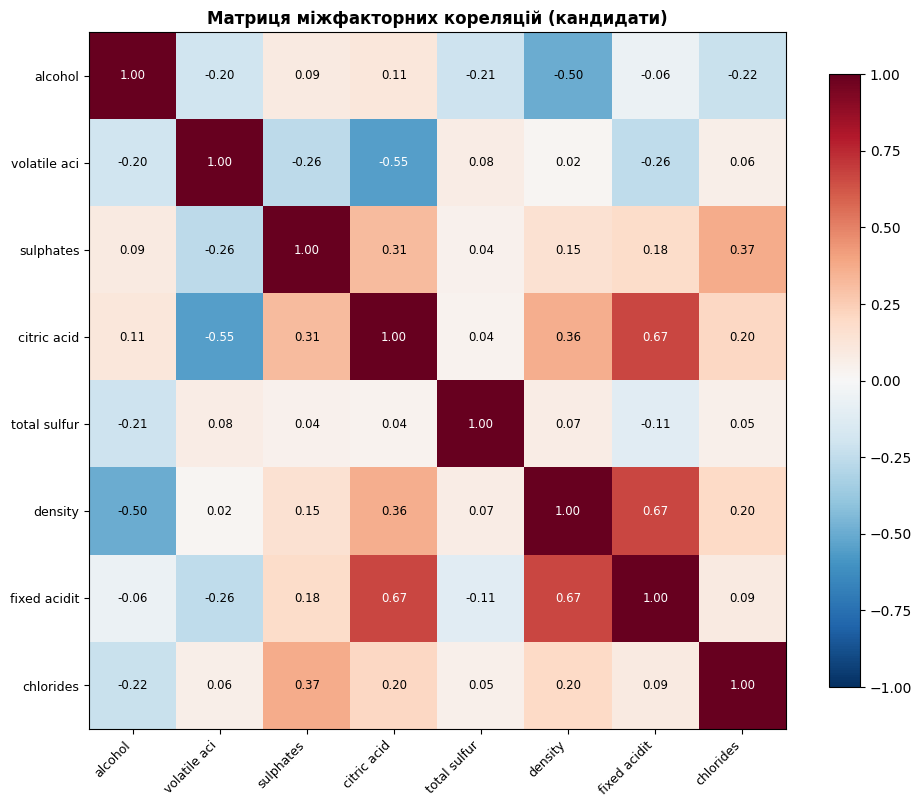

Знайдено пар з мультиколінеарністю: 0


In [82]:
COLLINEAR_THRESHOLD = 0.70

cm_factors = df[candidates].corr()

fig, ax = plt.subplots(figsize=(len(candidates) * 1.1 + 1, len(candidates) * 1.1))
im = ax.imshow(cm_factors.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(candidates)))
ax.set_yticks(range(len(candidates)))
short = [c[:12] for c in candidates]
ax.set_xticklabels(short, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(short, fontsize=9)
ax.set_title('Матриця міжфакторних кореляцій (кандидати)', fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.75)

collinear_pairs = []
for i in range(len(candidates)):
    for j in range(len(candidates)):
        v = cm_factors.values[i, j]
        c = 'white' if abs(v) > 0.55 else 'black'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8.5, color=c)
        if i < j and abs(v) >= COLLINEAR_THRESHOLD:
            collinear_pairs.append((candidates[i], candidates[j], v))
            for xi, yi in [(i, j), (j, i)]:
                ax.add_patch(plt.Rectangle((yi-0.5, xi-0.5), 1, 1,
                             fill=False, edgecolor='red', lw=2.5))

plt.tight_layout()
plt.show()

print(f'Знайдено пар з мультиколінеарністю: {len(collinear_pairs)}')

#### **Вибір факторів для ДФЕ**

Обираємо 4 фактори (ДФЕ 2^{4-1} = 8 дослідів) з найвищою абсолютною кореляцією:
- X₁ — alcohol (алкоголь)
- X₂ — volatile acidity (летка кислотність)
- X₃ — sulphates (сульфати)
- X₄ — citric acid (лимонна кислота)

In [83]:
FACTORS = {
    'X1': 'alcohol',
    'X2': 'volatile acidity',
    'X3': 'sulphates',
    'X4': 'citric acid',
}

Обчислення областей визначення факторів

In [84]:
params = {}

print("Таблиця 1 — Області визначення факторів та вихідної змінної\n")

factors = {}
for label, col in FACTORS.items():
    xmin, xmax = df[col].min(), df[col].max()
    x0 = (xmax + xmin) / 2
    dx = (xmax - xmin) / 2
    
    params[label] = {'x0': x0, 'dx': dx}
    factors[label] = {'col': col, 'min': xmin, 'max': xmax, 'x0': x0, 'dx': dx}
    
    print(f"{label} ({col}): [{xmin:.2f}, {xmax:.2f}] | Нул. рівень X0: {x0:.2f} | Інт. вар. ΔX: {dx:.2f}")

print(f"\ny ({TARGET}): [{df[TARGET].min()}, {df[TARGET].max()}]")

Таблиця 1 — Області визначення факторів та вихідної змінної

X1 (alcohol): [8.40, 14.90] | Нул. рівень X0: 11.65 | Інт. вар. ΔX: 3.25
X2 (volatile acidity): [0.12, 1.58] | Нул. рівень X0: 0.85 | Інт. вар. ΔX: 0.73
X3 (sulphates): [0.33, 2.00] | Нул. рівень X0: 1.17 | Інт. вар. ΔX: 0.83
X4 (citric acid): [0.00, 1.00] | Нул. рівень X0: 0.50 | Інт. вар. ΔX: 0.50

y (quality): [3, 8]


#### **TASK 1: Кодування вихідної інформації**

Виконуємо кодування кожного фактора за формулою: x_i = (X_i - X_i0) / ΔX_i

In [85]:
df_coded = df_clean.copy()
for label, factor in factors.items():
    df_coded[label] = (df_clean[factor['col']] - factor['x0']) / factor['dx']
    
print('Таблиця кодування (перші 8 рядків)\n')

show = pd.DataFrame()
for label, factor in factors.items():
    show[f'{label} ({factor["col"][:8]}..)'] = df[factor['col']].values[:8].round(3)
    show[f'{label}_код'] = df_coded[label].values[:8].round(3)
print(show.to_string(index=False))

Таблиця кодування (перші 8 рядків)

 X1 (alcohol..)  X1_код  X2 (volatile..)  X2_код  X3 (sulphate..)  X3_код  X4 (citric a..)  X4_код
            9.4  -0.692             0.70  -0.205             0.56  -0.725             0.00   -1.00
            9.8  -0.569             0.88   0.041             0.68  -0.581             0.00   -1.00
            9.8  -0.569             0.76  -0.123             0.65  -0.617             0.04   -0.92
            9.8  -0.569             0.28  -0.781             0.58  -0.701             0.56    0.12
            9.4  -0.692             0.70  -0.205             0.56  -0.725             0.00   -1.00
            9.4  -0.692             0.66  -0.260             0.56  -0.725             0.00   -1.00
            9.4  -0.692             0.60  -0.342             0.46  -0.844             0.06   -0.88
           10.0  -0.508             0.65  -0.274             0.47  -0.832             0.00   -1.00


Перевірка діапазону кодованих значень (має бути [- 1, + 1])

In [86]:
for label in factors:
    mn = df_coded[label].min(); mx = df_coded[label].max()
    print(f'  {label}: [{mn:.4f}, {mx:.4f}]')

  X1: [-1.0000, 1.0000]
  X2: [-1.0000, 1.0000]
  X3: [-1.0000, 0.0659]
  X4: [-1.0000, 0.5800]


#### **TASK 2: Вибір генерувальних співвідношень**

Будуємо повний ФЕ 2^3 для перших 3-х факторів, четвертий визначаємо через генерувальне співвідношення:
`x4 = x1 * x2 * x3`

In [87]:
k_base = 3  # к-ть базових факторів
k_total = 4  # загальна к-ть факторів
p = 1  # к-ть генерувальних співвідношень
N = 2**k_base  # к-ть дослідів

Побудова матриці планування ДФЕ 2^(4-1)

In [88]:
from itertools import product

base_levels = list(product([-1, 1], repeat=k_base))
plan = pd.DataFrame(base_levels, columns=['x1', 'x2', 'x3'])

plan['x4'] = plan['x1'] * plan['x2'] * plan['x3']

plan.insert(0, 'x0', 1)
plan['x1x2'] = plan['x1'] * plan['x2']
plan['x1x3'] = plan['x1'] * plan['x3']
plan['x2x3'] = plan['x2'] * plan['x3']

plan.index = range(1, N+1)
plan.index.name = 'Дослід'

In [89]:
print('Таблиця 2 — Матриця планування ДФЕ 2^(4-1)')
print('(x4 = x1·x2·x3 — генерувальне співвідношення)')
print()
print(plan.to_string())

Таблиця 2 — Матриця планування ДФЕ 2^(4-1)
(x4 = x1·x2·x3 — генерувальне співвідношення)

        x0  x1  x2  x3  x4  x1x2  x1x3  x2x3
Дослід                                      
1        1  -1  -1  -1  -1     1     1     1
2        1  -1  -1   1   1     1    -1    -1
3        1  -1   1  -1   1    -1     1    -1
4        1  -1   1   1  -1    -1    -1     1
5        1   1  -1  -1   1    -1    -1     1
6        1   1  -1   1  -1    -1     1    -1
7        1   1   1  -1  -1     1    -1    -1
8        1   1   1   1   1     1     1     1


Перевірка матриці на ортогональність

In [90]:
X_cols = ['x0','x1','x2','x3','x4','x1x2','x1x3','x2x3']
Xm = plan[X_cols].values.astype(float)
XtX = Xm.T @ Xm
is_orth = np.allclose(XtX - np.diag(np.diag(XtX)), 0)
print(f'\nМатриця ортогональна: {is_orth} (X^T·X = {N}·I)')


Матриця ортогональна: True (X^T·X = 8·I)


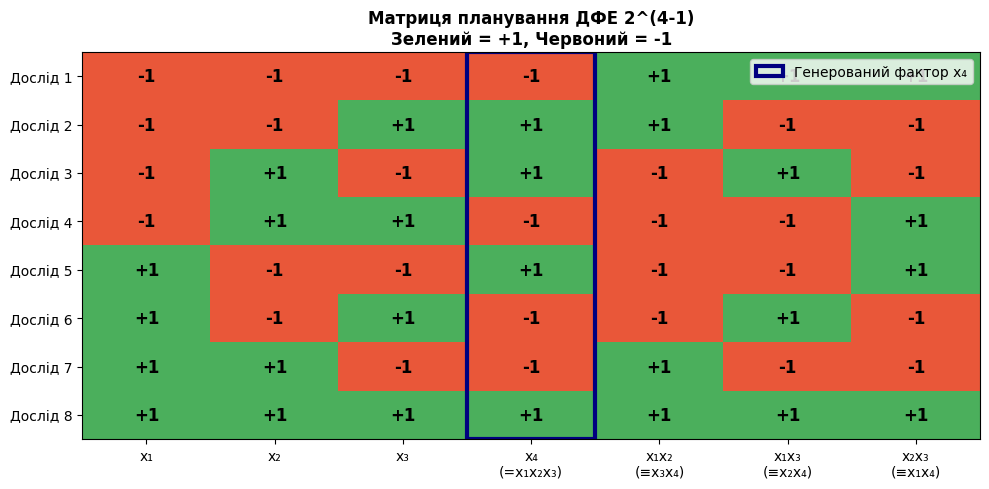

In [91]:
fig, ax = plt.subplots(figsize=(10, 5))
data_vis = plan[['x1','x2','x3','x4','x1x2','x1x3','x2x3']].values
im = ax.imshow(data_vis, cmap='RdYlGn', vmin=-1.5, vmax=1.5, aspect='auto')
ax.set_xticks(range(7))
ax.set_xticklabels(['x₁','x₂','x₃','x₄\n(=x₁x₂x₃)','x₁x₂\n(≡x₃x₄)','x₁x₃\n(≡x₂x₄)','x₂x₃\n(≡x₁x₄)'], fontsize=10)
ax.set_yticks(range(N))
ax.set_yticklabels([f'Дослід {i+1}' for i in range(N)])
ax.set_title('Матриця планування ДФЕ 2^(4-1)\nЗелений = +1, Червоний = -1', fontweight='bold')

for i in range(N):
    for j in range(7):
        val = int(data_vis[i, j])
        ax.text(j, i, f'{val:+d}', ha='center', va='center', fontweight='bold', fontsize=12)

# Виділяємо x4 як генерований
ax.add_patch(plt.Rectangle((2.5, -0.5), 1, N, fill=False,
             edgecolor='navy', linewidth=3, label='Генерований фактор x₄'))
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

#### **Формування вихідної таблиці**

Для кожного з 8 дослідів відбираємо відповідні спостереження з датасету та обчислюємо:
- $Y_{U1}, Y_{U2}, \ldots$ — повторні спостереження якості
- $\bar{Y}$ — середнє (результат «досліду»)
- $S_i^2$ — вибіркова дисперсія (для перевірки Кохрена)

Медіани факторів для розбиття

In [92]:
factor_cols = [info['col'] for info in factors.values()]
medians = {col: df[col].median() for col in factor_cols}

print('Медіани факторів (пороги рівнів):')
for label, info in factors.items():
    col = info['col']
    m = medians[col]
    print(f'  {label} ({col:20}): медіана = {m:.4f}')
    print(f'    рівень −1: X ≤ {m:.4f}  |  рівень +1: X > {m:.4f}')

Медіани факторів (пороги рівнів):
  X1 (alcohol             ): медіана = 10.2000
    рівень −1: X ≤ 10.2000  |  рівень +1: X > 10.2000
  X2 (volatile acidity    ): медіана = 0.5200
    рівень −1: X ≤ 0.5200  |  рівень +1: X > 0.5200
  X3 (sulphates           ): медіана = 0.6200
    рівень −1: X ≤ 0.6200  |  рівень +1: X > 0.6200
  X4 (citric acid         ): медіана = 0.2600
    рівень −1: X ≤ 0.2600  |  рівень +1: X > 0.2600


Обчислення y_mean та дисперсії для кожного досліду ДФЕ

In [93]:
base_factor_cols = [factors['X1']['col'],
                    factors['X2']['col'],
                    factors['X3']['col'],
                    factors['X4']['col']]
M_REPEATS = 5

In [94]:
results = []
for i, (lvl1, lvl2, lvl3) in enumerate(base_levels):
    lvl4 = lvl1 * lvl2 * lvl3
    lvls = [lvl1, lvl2, lvl3, lvl4]

    masks = []
    for lvl, col in zip(lvls, base_factor_cols):
        med = medians[col]
        masks.append(df[col] <= med if lvl == -1 else df[col] > med)
    mask = masks[0] & masks[1] & masks[2] & masks[3]

    subset = df.loc[mask, TARGET]
    n_obs  = len(subset)
    y_mean = subset.mean()
    y_var  = subset.var(ddof=1) if n_obs > 1 else 0.0

    sample_vals = subset.values[:M_REPEATS] if n_obs >= M_REPEATS else subset.values

    results.append({
        'x1': lvl1, 'x2': lvl2, 'x3': lvl3, 'x4': lvl4,
        'n_obs': n_obs,
        'y_mean': y_mean,
        'y_var': y_var,
        'repeats': sample_vals,
    })

results_df = pd.DataFrame(results)
results_df.index = range(1, N+1)
results_df.index.name = 'Дослід'

In [95]:
table2 = results_df[['x1','x2','x3','x4']].copy()

for m in range(M_REPEATS):
    table2[f'Y_U{m+1}'] = [r['repeats'][m] if m < len(r['repeats']) else np.nan for r in results]

table2['Ȳ'] = results_df['y_mean'].round(4)
table2['S²'] = results_df['y_var'].round(4)
table2['n'] = results_df['n_obs']

print('Таблиця 2 — Вихідні дані ДФЕ 2^(4-1)')
print()
print(table2.to_string())

Таблиця 2 — Вихідні дані ДФЕ 2^(4-1)

        x1  x2  x3  x4  Y_U1  Y_U2  Y_U3  Y_U4  Y_U5       Ȳ      S²    n
Дослід                                                                   
1       -1  -1  -1  -1     5     5     5     5     5  5.2817  0.3195   71
2       -1  -1   1   1     6     5     7     5     5  5.6992  0.6058  133
3       -1   1  -1   1     4     6     6     5     5  5.1385  0.3399   65
4       -1   1   1  -1     5     5     5     5     5  5.2793  0.3486  111
5        1  -1  -1   1     6     6     6     6     5  5.9623  0.5128  106
6        1  -1   1  -1     6     5     5     6     6  6.1556  0.4980   45
7        1   1  -1  -1     6     6     5     5     5  5.4752  0.6940  141
8        1   1   1   1     6     5     7     7     7  6.1471  0.6747   34


#### **TASK 3: Розрахунок коефіцієнтів рівнянь**

Матриця ортогональна -> визначаємо коефіцієнти планування за формулою: b = (1/N) * X^T * y

In [96]:
X_plan = plan[X_cols].values.astype(float)
y_bar  = results_df['y_mean'].values
b = (X_plan.T @ y_bar) / N

In [97]:
coef_names  = ['b0',  'b1',  'b2',  'b3',  'b4',  'b12',   'b13',   'b23']
coef_alias  = ['',    '',    '',    '',    'b123','b34',   'b24',   'b14']
coef_labels = [
    'Вільний член',
    'Алкоголь (X₁)',
    'Летка кислотність (X₂)',
    'Сульфати (X₃)',
    'Лимонна кислота (X₄)  [≡ b₁₂₃]',
    'Взаємодія x₁x₂  [≡ b₃₄]',
    'Взаємодія x₁x₃  [≡ b₂₄]',
    'Взаємодія x₂x₃  [≡ b₁₄]',
]

coef_df = pd.DataFrame({
    'Коефіцієнт': coef_names,
    'Змішаний з': coef_alias,
    'Значення': b,
    'Опис': coef_labels
}).set_index('Коефіцієнт')

print('Таблиця 3 — Коефіцієнти рівняння регресії ДФЕ')
print()
print(coef_df.to_string())

Таблиця 3 — Коефіцієнти рівняння регресії ДФЕ

           Змішаний з  Значення                            Опис
Коефіцієнт                                                     
b0                     5.642342                    Вільний член
b1                     0.292672                   Алкоголь (X₁)
b2                    -0.132348          Летка кислотність (X₂)
b3                     0.177944                   Сульфати (X₃)
b4               b123  0.094416  Лимонна кислота (X₄)  [≡ b₁₂₃]
b12               b34  0.008452         Взаємодія x₁x₂  [≡ b₃₄]
b13               b24  0.038350         Взаємодія x₁x₃  [≡ b₂₄]
b23               b14  0.025231         Взаємодія x₂x₃  [≡ b₁₄]


Формулюємо рівняння

In [98]:
var_map = {'b0':'', 'b1':'x₁', 'b2':'x₂', 'b3':'x₃', 'b4':'x₄', 'b12':'x₁x₂', 'b13':'x₁x₃', 'b23':'x₂x₃'}

terms = []
for name, bj in zip(coef_names, b):
    vi = var_map[name]
    if vi == '':
        terms.append(f'{bj:.4f}')
    elif bj >= 0:
        terms.append(f'+ {bj:.4f}·{vi}')
    else:
        terms.append(f'- {abs(bj):.4f}·{vi}')
        
print('Рівняння регресії:\n')
print('ŷ = ' + ' '.join(terms))

Рівняння регресії:

ŷ = 5.6423 + 0.2927·x₁ - 0.1323·x₂ + 0.1779·x₃ + 0.0944·x₄ + 0.0085·x₁x₂ + 0.0383·x₁x₃ + 0.0252·x₂x₃


#### **TASK 4: Перевірка однорідності дисперсій**

Критерій Корхена

#### **TASK 5: Перевірка значущості коефіцієнта рівняння регресії**

t-критерій Стьюдента

#### **TASK 6: Перевірка адекватності математичної моделі**

Критерій Фішера